In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-04-15 09:54:56.987293: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/AB-DOR/calslope/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/AB-DOR/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/AB-DOR/calslope/"
    uncal_path = "/Users/mcha5804/JWST/AB-DOR/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/AB-DOR/")
output_path = os.path.join(cache, "outputs/AB-DOR/")

state = np.load(
    os.path.join(model_cache, "conv_up_model.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
def truncate_files(files, ngroups):
    """
    Truncate the ramp of files to only have ngroups.
    """
    # TODO do one_on_fs here

    for file in files:

        top_group = file["RAMP"].data.shape[0]
        up_to = top_group - ngroups

        # files are mutable, so they will change in place
        for attr in ["RAMP", "SLOPE", "RAMP_ERR", "RAMP_SUP", "SLOPE_SUP"]:
            file[attr].data = file[attr].data[:-up_to, ...]

        file["SLOPE_ERR"].data = file["SLOPE_ERR"].data[:-up_to, :-up_to, ...]

In [4]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        if file[0].header["TARGPROP"] != "AB-DOR" or file[0].header["NGROUPS"] != 13:
            continue
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        if (
            file[0].header["TARGPROP"] == "HD-36805"
            or file[0].header["TARGPROP"] == "HD-37093"
            or file[0].header["TARGPROP"] == "HD-37093"
        ):
            cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
# dorito.misc.truncate_files(sci_files, 18)
# truncate_files(sci_files, 18)

In [5]:
import jax.random as jr
from amigo.rnn_models import PixelNonLinearity, ConvRNN, RNNRamp

ramp_model = ConvRNN(key=jr.key(0), use_bias=False, bias_value=1e-3)
ramp_model = RNNRamp(ramp_model, gain_model=PixelNonLinearity())

In [6]:
source_size = 80
# level = 5
# # shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
# wavelets = dorito.wavelets.Wavelets(
#     np.ones((source_size, source_size)), level=level, wavelet="db2"
# )

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    # cal_files[0:5],
    # cal_files,
    [],
    # sci_files[3:4],
    sci_files,
    # [],
    state=state,
    modeller=dorito.models.ResolvedAmigoModel,
    ramp_model=ramp_model,
    extra_priors={
        # "approx": np.log10(wavelets.approx),
        # "details": wavelets.values,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    sci_fit=dorito.model_fits.DynamicResolvedFit,
    # sci_fit=dorito.model_fits.ResolvedFit,
    # sci_fit=amigo.model_fits.PointFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# init state
init_state = np.load(init_state_cache + "F480M_5.npy", allow_pickle=True)[()]
for p in [
    "positions",
    "fluxes",
    "aberrations",
    # "log_distribution",
]:
    for key in init_state[p].keys():
        params[p][key] = init_state[p][key]

    # params[p] = init_state[p]
model = model.set("params", params)

model = model.set("FF", np.load(os.path.join(model_cache, "FF.npy")))
model = model.set(
    "non_linearity", np.load(os.path.join(model_cache, "non_linearities.npy"))
)

In [7]:
sci_keys = []
for exp in fits:
    if not exp.calibrator:
        sci_keys.append(exp.map_param("positions"))


def kill_pos_grads(model, grads, args):
    grads = grads.multiply(sci_keys, 0.0)
    return grads, args


eps = 1e1


def term_looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.2f}")

    if len(list(loss_dict.values())[0]) > 10:
        last_loss = np.array([v[-2] for v in loss_dict.values()]).mean(0)
        if np.abs(last_loss - loss) < eps:
            return True

    return False

In [15]:
n_epoch = 500

config = {
    # "positions": sgd(1e-1, 0),
    # "positions": sgd(5e-3, 0),
    "fluxes": sgd(2e-1, 0),
    # "fluxes": sgd(3e-2, 0),
    # "aberrations": sgd(5e-2, 4),
    # "log_distribution": adam(7e-2, 0),  # , (10, 0.25), b1=0.7),
    "log_distribution": adam(3e-2, 10),  # , (10, 0.25), b1=0.7),
    # "positions": sgd(2e-2, 10),
    # "fluxes": sgd(2e-2, 0),
    # "one_on_fs": sgd(1e2, 6),
    # "approx": adam(1e-5, 0),
    # "approx": adam(6e-3, 8),
    # "details": adam(6e-9, 15),
    # "approx": adam(2e-2, 8),
    # "details": adam(2e-8, 15),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 2.0e3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e6,
    # "QV": 1.0e-3,
    # "ME": 1.0e2,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        # "L1": dorito.stats.L1_on_wavelets,
        # "L1": L1_on_wavelets,
        # "QV": dorito.stats.TSV,
        # "ME": dorito.stats.ME,
    },
    # "mask": mask,
}

trainer = amigo.fitting.Trainer(
    dorito.stats.regularised_loss_fn,
    norm_fn=dorito.stats.normalise_distribution,
    # grad_fn=kill_pos_grads,
    cache=fisher_cache,
    # looper_fn=term_looper,
)

trainer = trainer.update_fishers(
    model.set("ramp.bleed", False),
    # model,
    fits,
    args=args,
    verbose=True,
    parameters=[
        "positions",
        "fluxes",
        "aberrations",
        # "one_on_fs",
        # "log_distribution",
        # "spectral_coeffs",
    ],
)

# Train the model
result = trainer.train(
    model=model,
    # model=model.set("ramp.values", np.zeros_like(model.ramp.values)),
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
    args=args,
)

# balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 17,623,308.91
Estimated run time: 0:01:19
Full Time: 0:01:32
Final Loss: 1,710,110.89


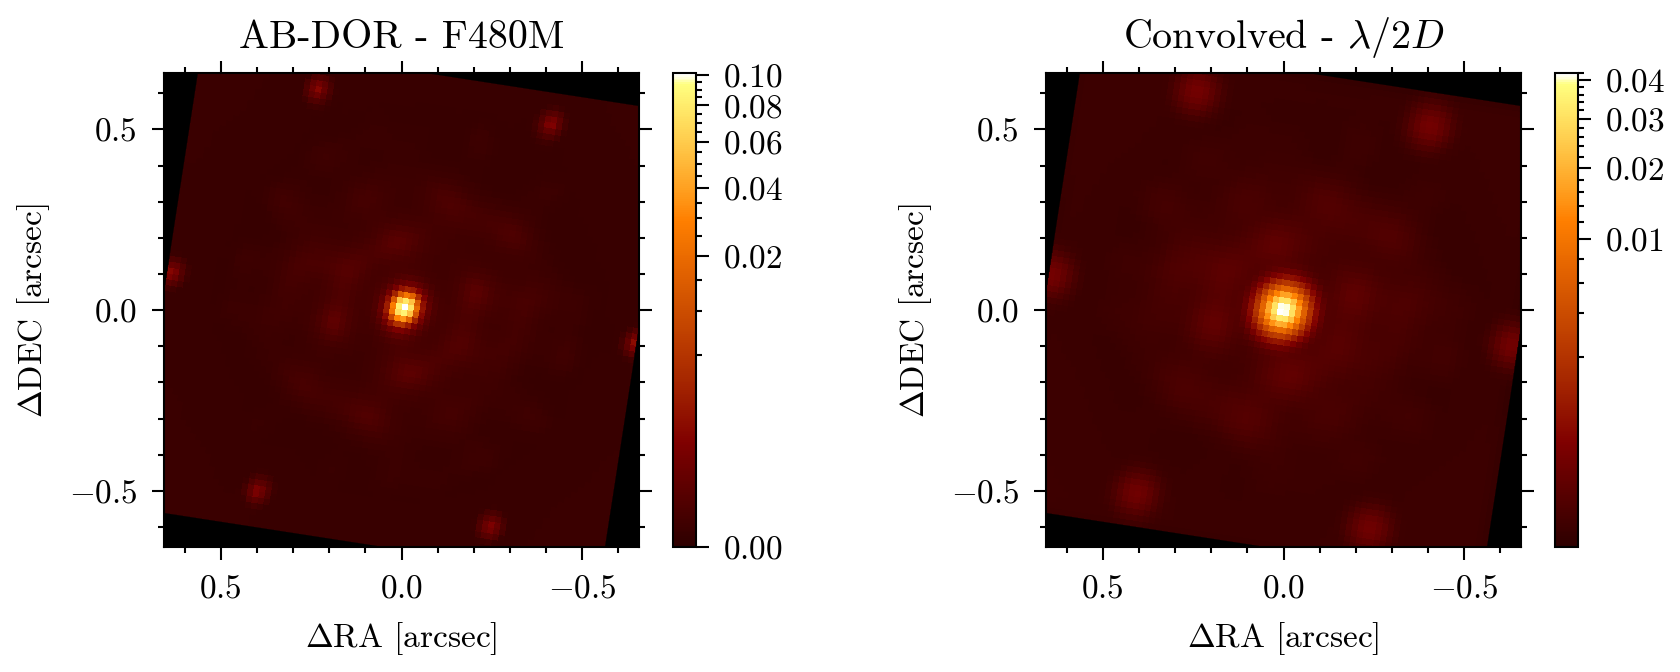

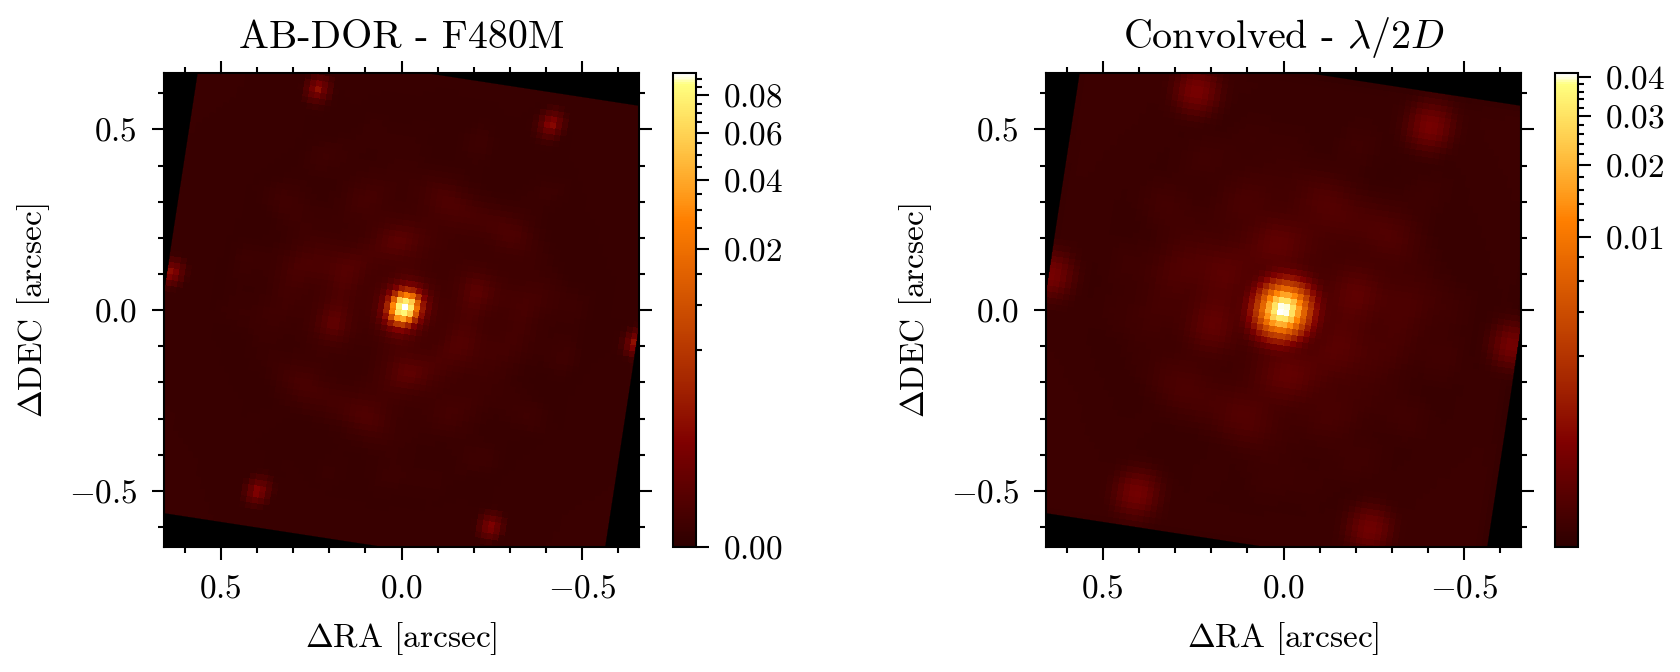

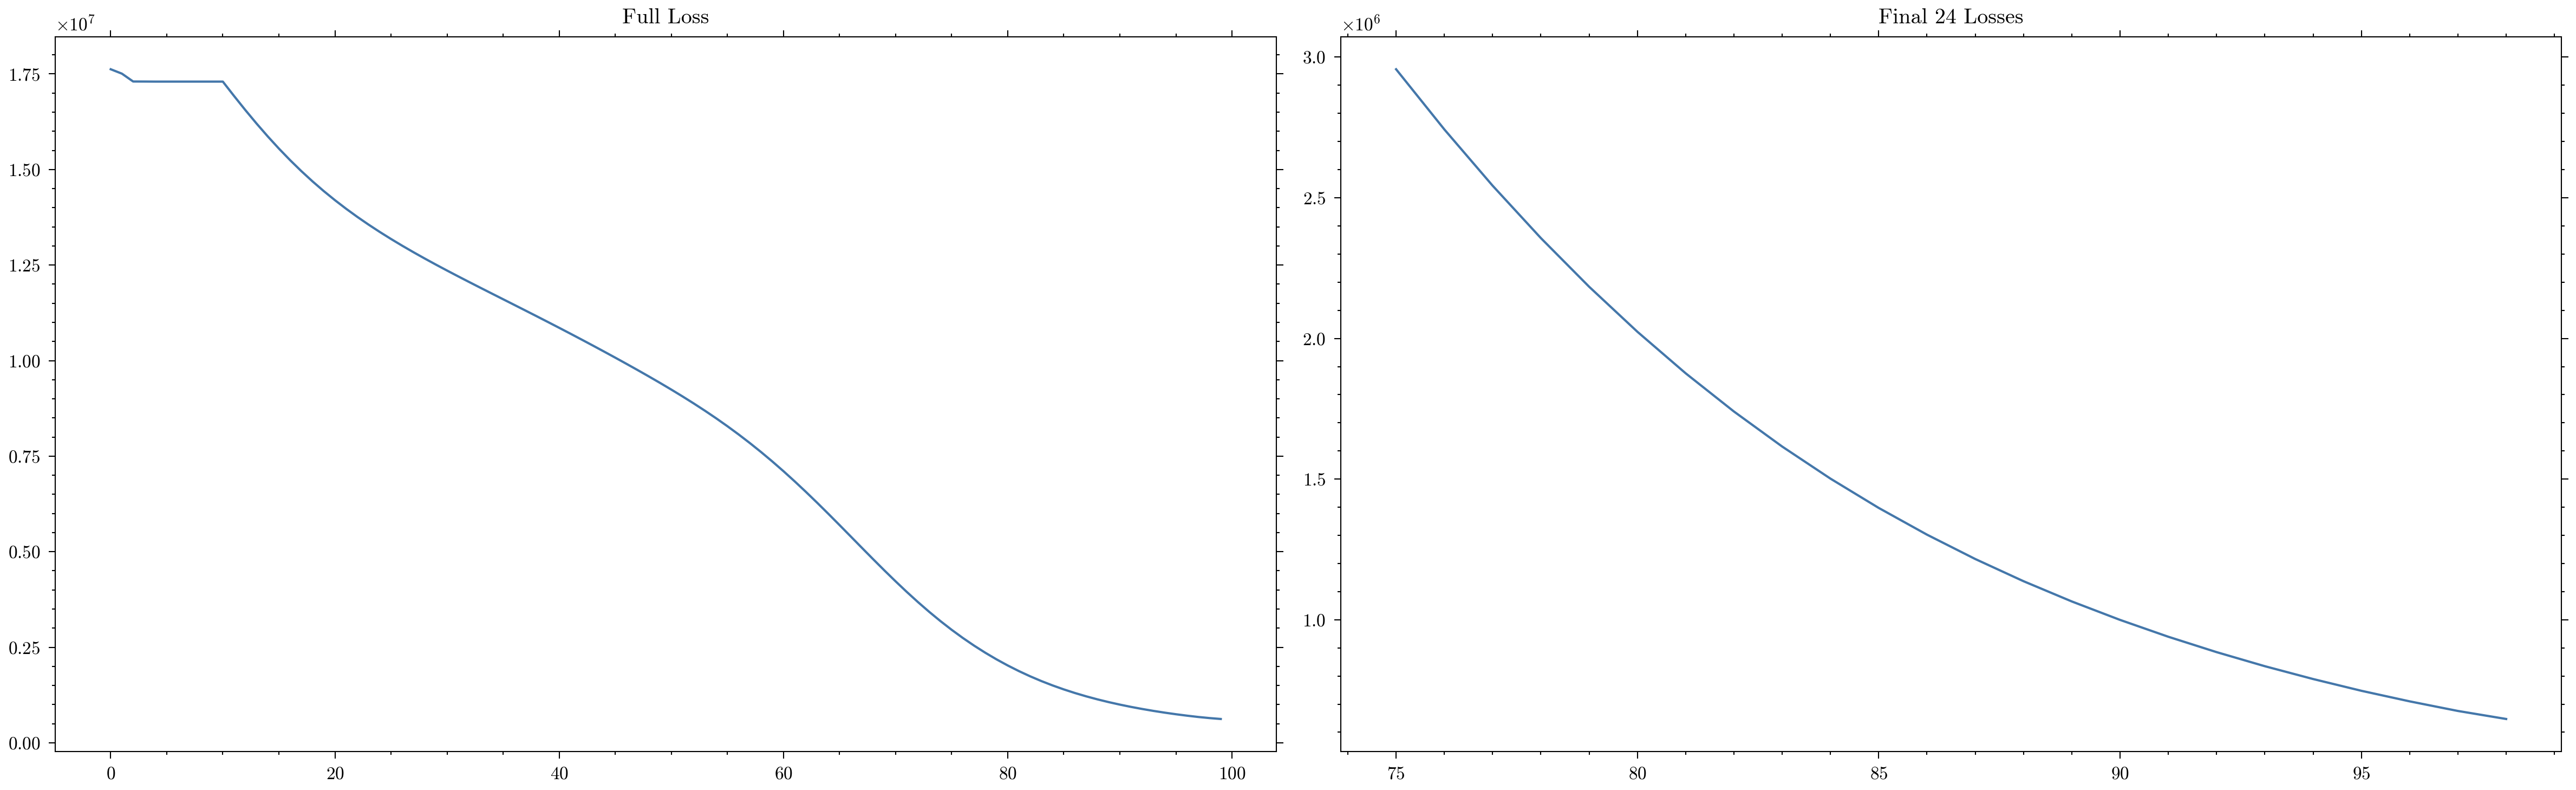

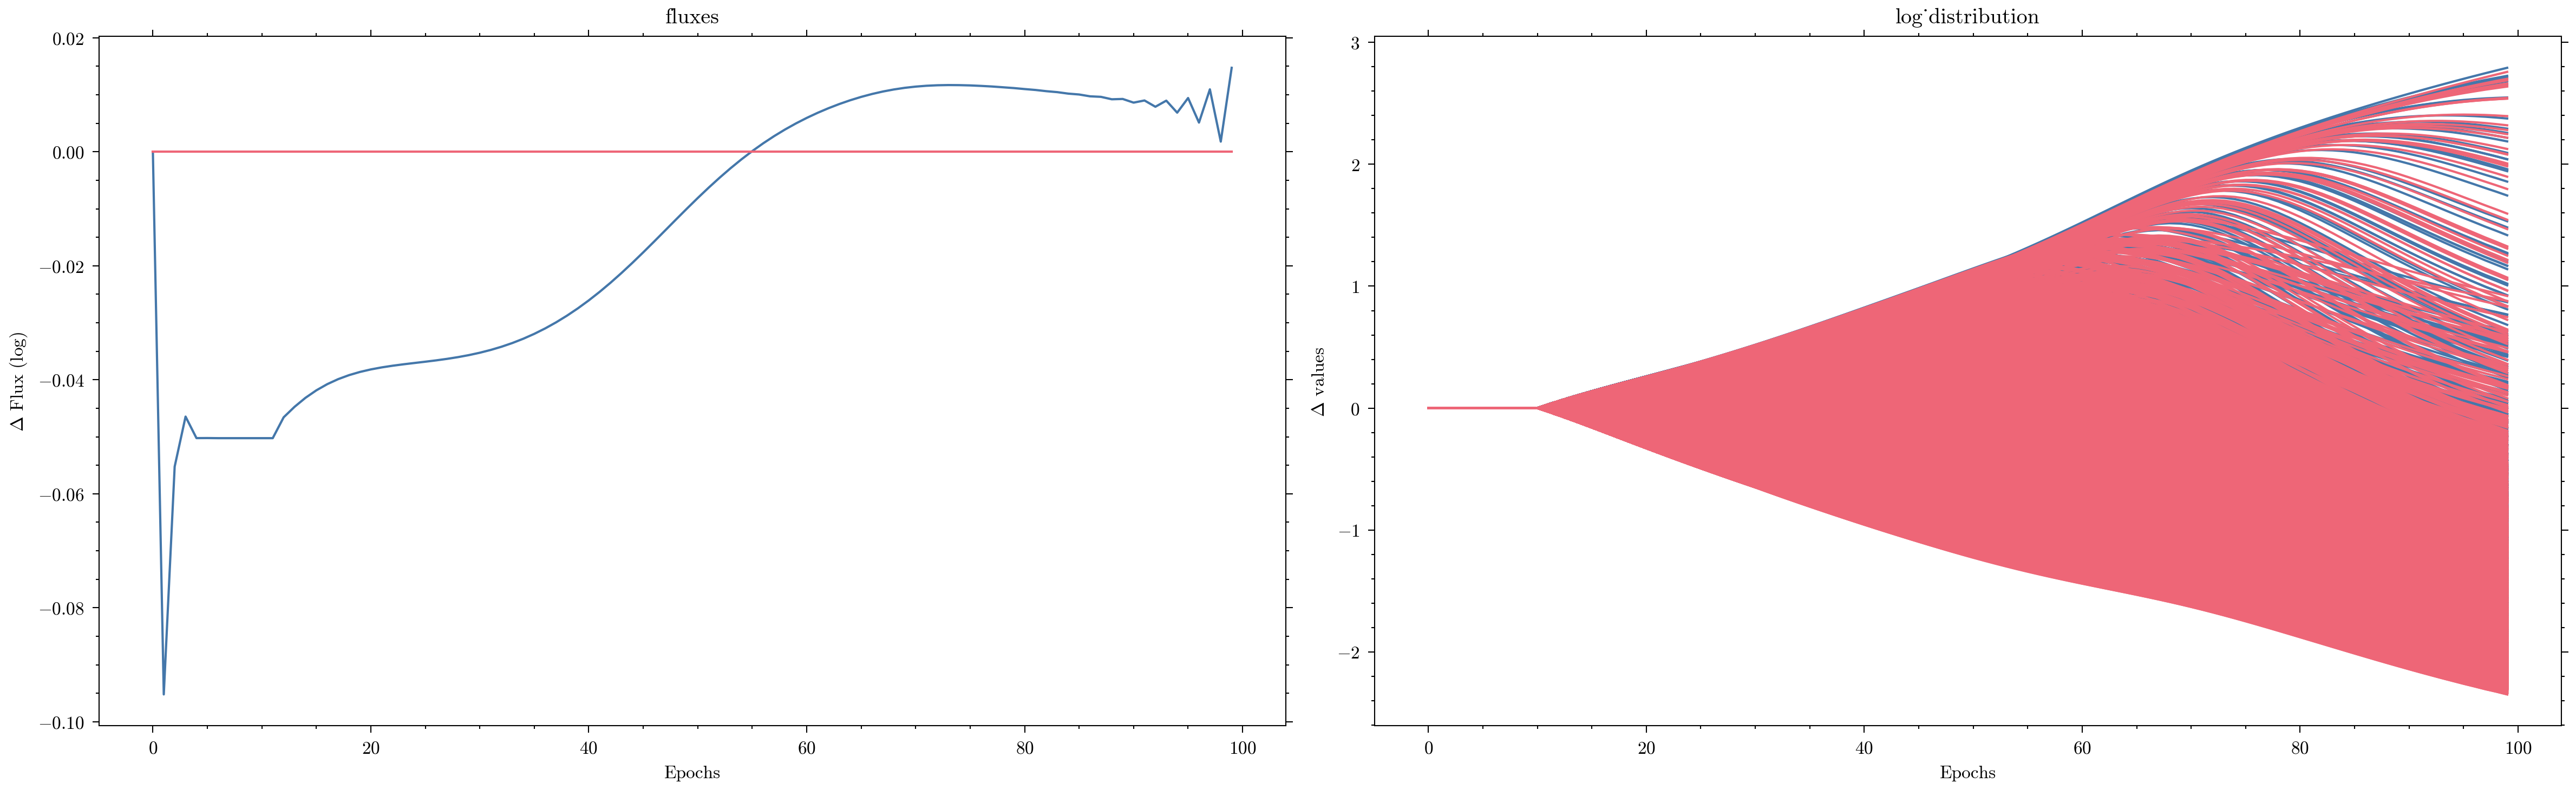

File 01093_012_05_03_1
Star AB-DOR
Filter F480M
nints 29
ngroups 13



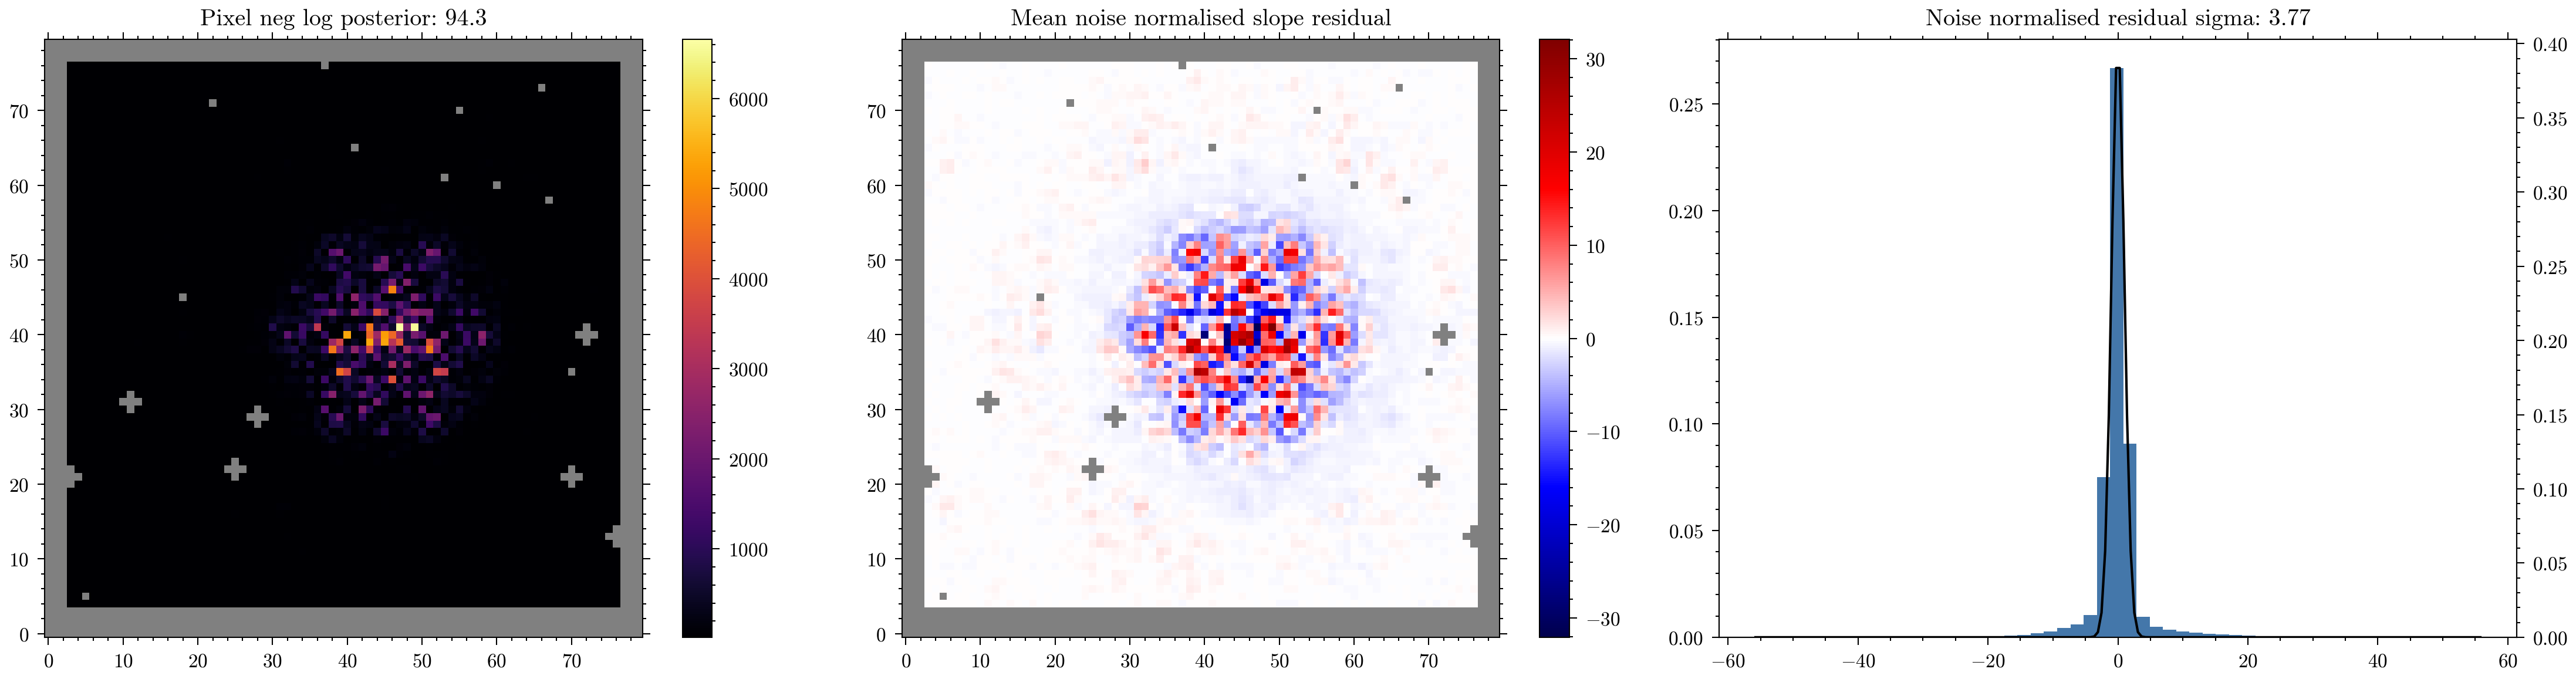

File 01093_013_05_03_1
Star AB-DOR
Filter F480M
nints 29
ngroups 13



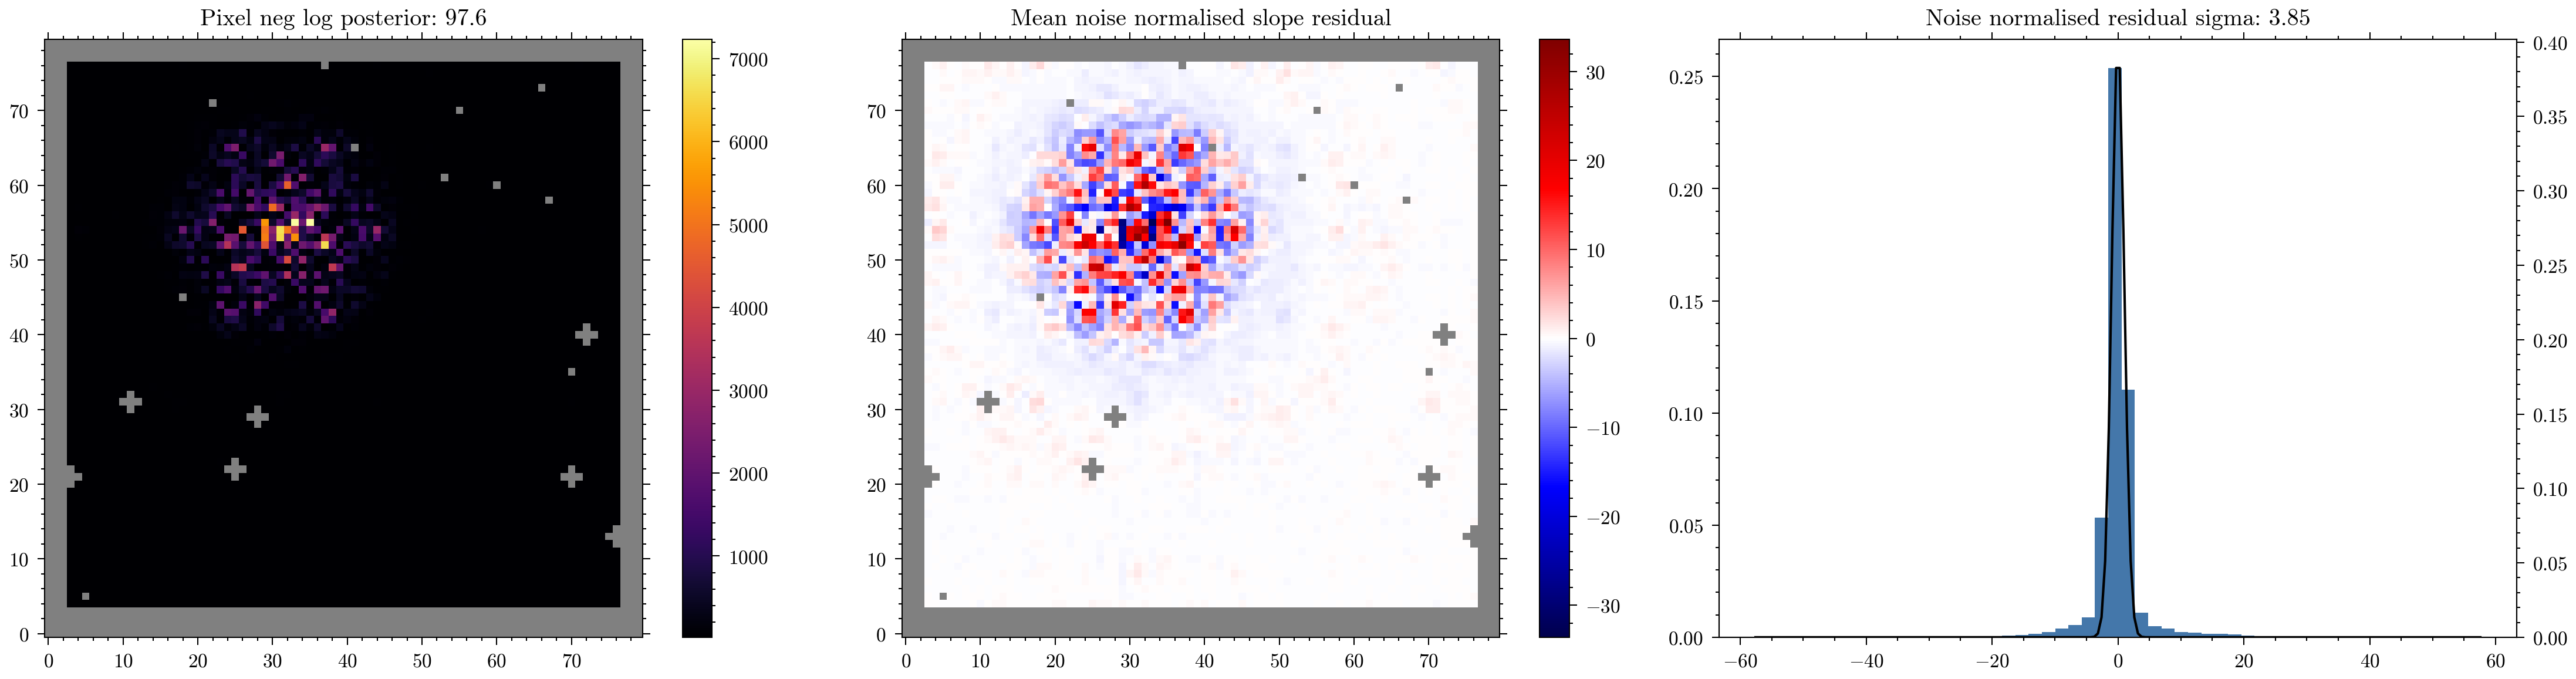

In [14]:
# np.save(init_state_cache + "F480M_5.npy", result.model.params)

flag = False
for exp in fits:

    try:
        if not flag:
            try:
                dist = result.model.get_distribution(exp)
            except:
                dist = exp.get_distribution(result.model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                vmin=0,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, result.model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                vmin=None,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"AB-DOR - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(output_path + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        # flag = True
    except:
        continue

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        result.model,
        exp,
        # test_model,
    )

(array([0.00309278, 0.00154639, 0.00773196, 0.01082474, 0.0185567 ,
        0.03092784, 0.02628866, 0.04793814, 0.07113402, 0.07113402,
        0.0742268 , 0.08814433, 0.11907216, 0.12216495, 0.10979381,
        0.14381443, 0.11907216, 0.11907216, 0.07268041, 0.08969072,
        0.04948454, 0.05257732, 0.03247423, 0.02010309, 0.00927835,
        0.02010309, 0.00309278, 0.00463918, 0.00463918, 0.00309278]),
 array([ 90.7       ,  91.34666667,  91.99333333,  92.64      ,
         93.28666667,  93.93333333,  94.58      ,  95.22666667,
         95.87333333,  96.52      ,  97.16666667,  97.81333333,
         98.46      ,  99.10666667,  99.75333333, 100.4       ,
        101.04666667, 101.69333333, 102.34      , 102.98666667,
        103.63333333, 104.28      , 104.92666667, 105.57333333,
        106.22      , 106.86666667, 107.51333333, 108.16      ,
        108.80666667, 109.45333333, 110.1       ]),
 <BarContainer object of 30 artists>)

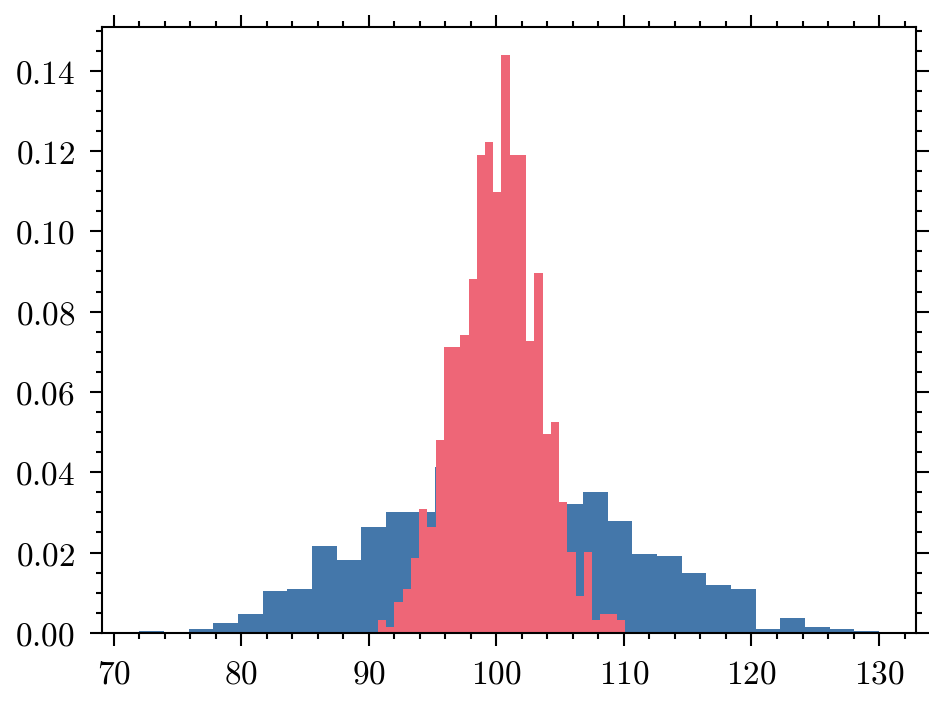

In [10]:
from scipy import stats

poisson = stats.poisson(mu=100)
rvs = poisson.rvs(1000)
poisson2 = stats.poisson(mu=1000)
rvs2 = poisson2.rvs(1000) / 10
plt.hist(rvs, bins=30, density=True)
plt.hist(rvs2, bins=30, density=True)